In [ ]:
### Setup

## Imports
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from scipy.stats import pearsonr

## Data Loading
df = pd.read_csv('../dataset/online_retail.csv')

## Data Cleaning
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype('Int64')

df['Cancelled'] = df['InvoiceNo'].str.startswith('C')
df['InvoiceNo'] = df['InvoiceNo'].mask(df['Cancelled'],df['InvoiceNo'].str[1:])

df = df[(df.StockCode.str.len() <= 6) & (df.StockCode.str.isnumeric())]

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Removed rows documenting product damage
df = df.drop(index=df[(df.Quantity < 0) & (~df.Cancelled)].index)

# Separating Data
df_full = df.copy()
df = df[~df.Cancelled].copy()

In [11]:
# Create Grouped Dataset
df = df_full[~df_full.Cancelled].copy()
customer_info = df.drop_duplicates('CustomerID')
customers_group = df.groupby('CustomerID', observed=True)['TotalPrice'].agg(TotalRevenue='sum').sort_values(by='TotalRevenue', ascending=False)
customers_group = customers_group.merge(customer_info[['CustomerID', 'Country']], on='CustomerID', how='left')

# Create Customer Revenue Bands
customers_group['RevenueBand'] = pd.cut(
    customers_group['TotalRevenue'], 
    bins=[0,1000,10000,float('inf')], 
    labels=['Low', 'Medium', 'High']
)
df = df.merge(customers_group[['CustomerID', 'RevenueBand']], on='CustomerID', how='left')

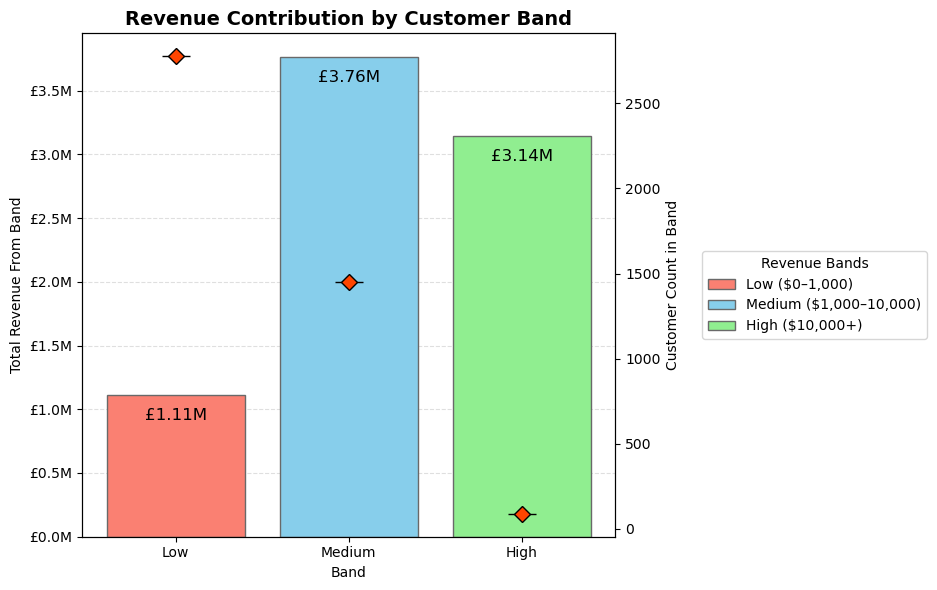

In [ ]:
### Customer Revenue Band Analysis


# Setup
RevenueBand_counts = customers_group['RevenueBand'].value_counts()
RevenueBand_sums = customers_group.groupby('RevenueBand', observed=True)['TotalRevenue'].sum()

fig, ax1 = plt.subplots(figsize=(7,6))
colors = ['salmon', 'skyblue', 'lightgreen', 'khaki', 'plum']


# Revenue
bars1 = ax1.bar(x=RevenueBand_sums.index, height=RevenueBand_sums, color=colors, edgecolor='dimgray')

ax1.grid(axis='y', ls='--', alpha=0.4)
ax1.set_axisbelow(True)

ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'£{y/1000000:.1f}M'))
ax1.bar_label(bars1, [f'£{x/1000000:.2f}M' for x in RevenueBand_sums], padding=-20, fontsize='12')

ax1.set_title('Revenue Contribution by Customer Band', fontsize=14, weight='bold')
ax1.set_xlabel('Band')
ax1.set_ylabel('Total Revenue From Band')


# Customer
ax2 = ax1.twinx()

ax2.plot(RevenueBand_counts, marker='_', color='orangered', linestyle='None', markeredgecolor='black', ms=20)
ax2.plot(RevenueBand_counts, marker='D', color='orangered', linestyle='None', markeredgecolor='black', ms=8)

labels1 =  [f'£{x/1000000:.2f}M' for x in RevenueBand_sums]
ax2.set_ylabel('Customer Count in Band')


# Finish
fig.legend(bars1, ['Low ($0–1,000)', 'Medium ($1,000–10,000)', 'High ($10,000+)'], title='Revenue Bands', bbox_to_anchor=(1, 0.5), loc='center left')

fig.tight_layout()
plt.savefig('../assets/4_CustomerRevenueByBand.png', dpi=200)


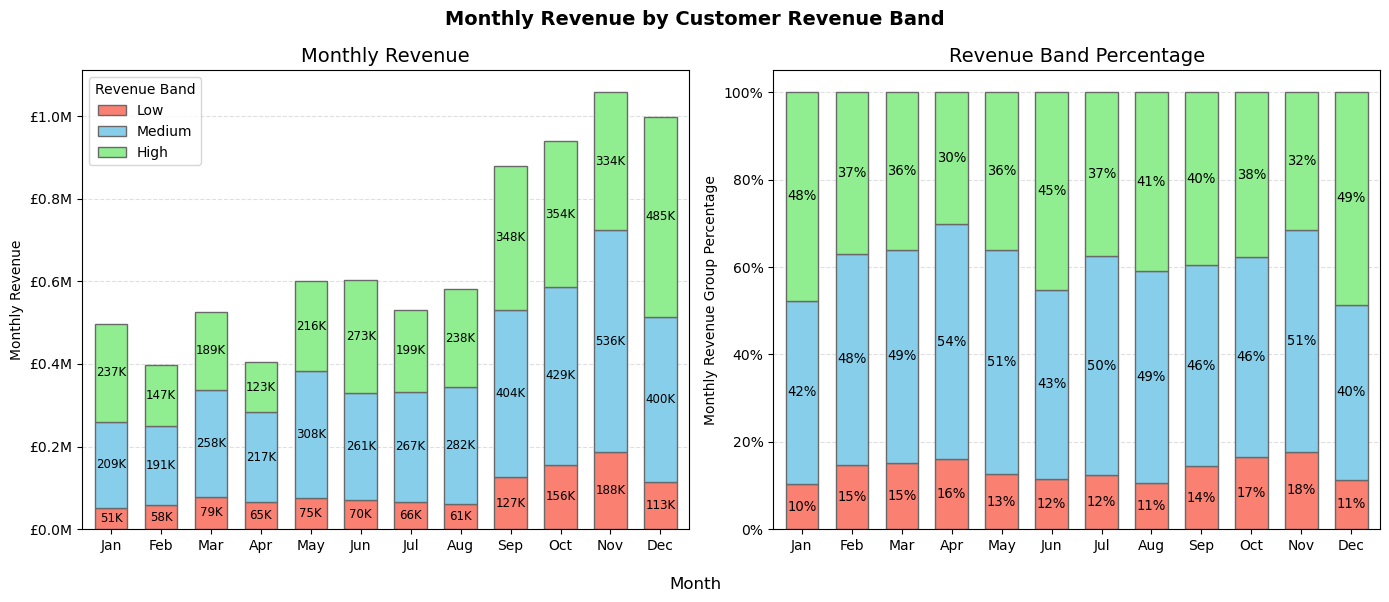

In [ ]:
### Monthly Revenue Analysis

# Setup
month_revenue = df.groupby([df.InvoiceDate.dt.month,'RevenueBand'], observed=True)['TotalPrice'].sum().unstack(fill_value=0)
month_revenue_percent = month_revenue.div(month_revenue.sum(axis=1), axis=0)

fig, ax = plt.subplots(1,2, figsize=(14,6))
colors = ['salmon', 'skyblue', 'lightgreen', 'khaki', 'plum']
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


# Revenue Bars
month_revenue.plot(ax=ax[0], kind='bar', stacked=True, color=colors, edgecolor='dimgray', width=0.65)

ax[0].grid(axis='y', linestyle='--', alpha=0.4)
ax[0].set_axisbelow(True)

ax[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'£{x/1000000:.1f}M'))
ax[0].set_xticklabels(months)
ax[0].tick_params(rotation=0)

for container in ax[0].containers:
    ax[0].bar_label(container, fmt=lambda x: f'{x/1000:.0f}K', label_type='center', fontsize=8.5, color='black')

fig.suptitle('Monthly Revenue by Customer Revenue Band', fontsize=14, fontweight='bold')
fig.supxlabel('Month')
ax[0].set_title('Monthly Revenue', fontsize=14)
ax[0].set_xlabel('')
ax[0].set_ylabel('Monthly Revenue')
ax[0].legend(title='Revenue Band') 


# Percentage Bars
bars = month_revenue_percent.plot(ax=ax[1], kind='bar', stacked=True, color=colors, edgecolor='dimgray', legend=False, width=0.65)

ax[1].grid(axis='y', linestyle='--', alpha=0.4)
ax[1].set_axisbelow(True)

ax[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax[1].set_xticklabels(months)
ax[1].tick_params(rotation=0)

for container in ax[1].containers:
    ax[1].bar_label(container, fmt=lambda x: f'{x*100:.0f}%', label_type='center', fontsize=9.5, color='black')

ax[1].set_title('Revenue Band Percentage', fontsize=14)
ax[1].set_xlabel('')
ax[1].set_ylabel('Monthly Revenue Group Percentage')


# Finish
fig.tight_layout()
plt.savefig('../assets/5_MonthlyRevenue.png', dpi=200)

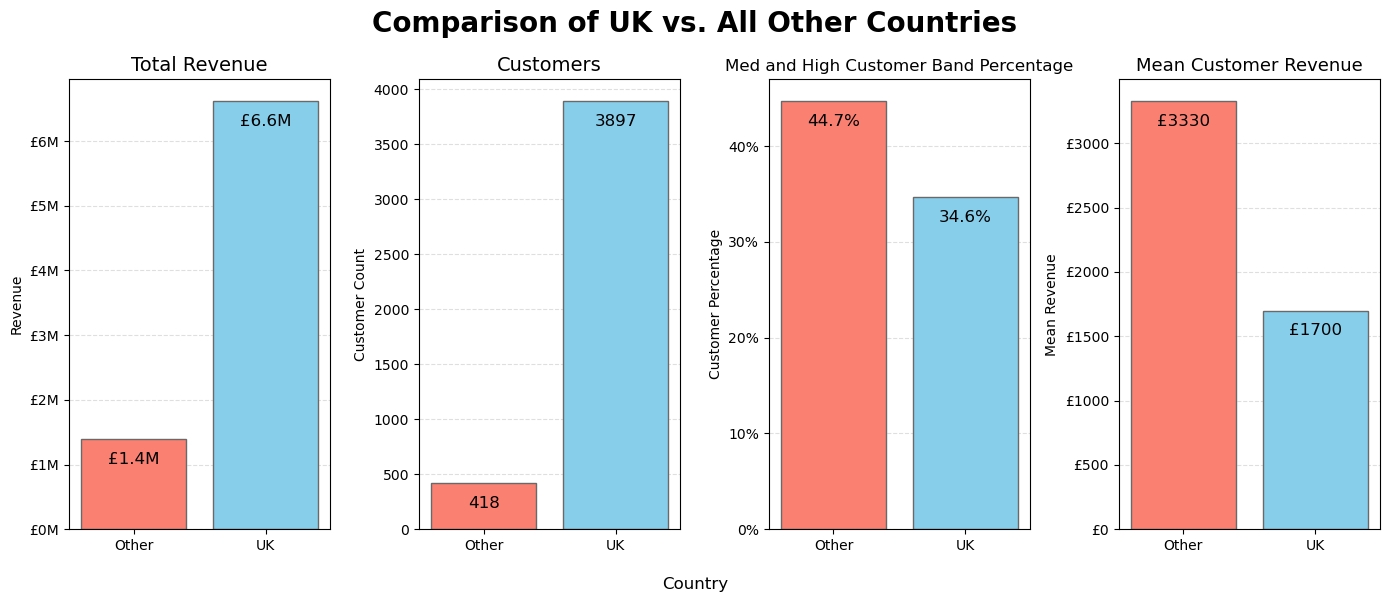

In [ ]:
### Country Revenue Analysis


## Setup
# Calculations
country_group = customers_group.groupby('Country', observed=True)['TotalRevenue'].agg(TotalRevenue='sum', CustomerCount='count')
band_counts = customers_group.groupby(['Country', 'RevenueBand'], observed=True)['RevenueBand'].count().unstack(fill_value=0)
country_group = country_group.reset_index().merge(band_counts.reset_index(), on='Country').set_index('Country')
country_group['MedHighCount'] = country_group['Medium'] + country_group['High']

uk_group = country_group.groupby(country_group.index=='United Kingdom', observed=True)[['TotalRevenue', 'CustomerCount', 'MedHighCount']].agg(
    TotalRevenue=('TotalRevenue','sum'),
    CustomerCount=('CustomerCount','sum'),
    MedHighCount=('MedHighCount','sum')
)
uk_group['MeanCustomerRevenue'] = uk_group['TotalRevenue'] / uk_group['CustomerCount']
uk_group['MedHighPercent'] = uk_group['MedHighCount']/uk_group['CustomerCount']
uk_group.index = ['Other', 'UK']

# Figure Creation
fig, ax = plt.subplots(1,4, figsize=(14,6))
colors = ['salmon', 'skyblue', 'lightgreen', 'khaki', 'plum']



## Revenue
bar1 = ax[0].bar(height=uk_group['TotalRevenue'], x=uk_group.index, color=colors, edgecolor='dimgrey')

ax[0].grid(axis='y', linestyle='--', alpha=0.4)
ax[0].set_axisbelow(True)

ax[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'£{y/1000000:.0f}M'))
ax[0].bar_label(bar1, labels=[f'£{y/1000000:.1f}M' for y in uk_group['TotalRevenue']], padding=-20, fontsize='12')

fig.suptitle('Comparison of UK vs. All Other Countries', weight='bold', fontsize=20)
fig.supxlabel('Country')
ax[0].set_title('Total Revenue', fontsize=14)
ax[0].set_ylabel('Revenue')

# Customers
bar2 = ax[1].bar(height=uk_group['CustomerCount'], x=uk_group.index, color=colors, edgecolor='dimgrey')

ax[1].grid(axis='y', linestyle='--', alpha=0.4)
ax[1].set_axisbelow(True)

ax[1].bar_label(bar2, labels=[f'{y:.0f}' for y in uk_group['CustomerCount']], padding=-20, fontsize='12')
ax[1].set_title('Customers', fontsize=14)
ax[1].set_ylabel('Customer Count')

# Band Percentage
bar3 = ax[2].bar(height=uk_group['MedHighPercent'], x=uk_group.index, color=colors, edgecolor='dimgrey')

ax[2].grid(axis='y', linestyle='--', alpha=0.4)
ax[2].set_axisbelow(True)

ax[2].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax[2].bar_label(bar3, labels=[f'{y*100:.1f}%' for y in uk_group['MedHighPercent']], padding=-20, fontsize='12')

ax[2].set_title('Med and High Customer Band Percentage', fontsize=12)
ax[2].set_ylabel('Customer Percentage')

# Mean Revenue
bar4 = ax[3].bar(height=uk_group['MeanCustomerRevenue'], x=uk_group.index, color=colors, edgecolor='dimgrey')

ax[3].grid(axis='y', linestyle='--', alpha=0.4)
ax[3].set_axisbelow(True)

ax[3].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'£{y:.0f}'))
ax[3].bar_label(bar4, labels=[f'£{y:.0f}' for y in uk_group['MeanCustomerRevenue']], padding=-20, fontsize='12')

ax[3].set_title('Mean Customer Revenue', fontsize=13)
ax[3].set_ylabel('Mean Revenue')

# Finish
fig.tight_layout()
plt.savefig('../assets/6_UKvsOther.png', dpi=200)